In [1]:
import pandas as pd
import os
from skimage.transform import resize
from skimage.io import imread
import numpy as np
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import kagglehub

In [2]:
# construct classes array
path = kagglehub.dataset_download("ossossh/solar-pannels-image-enhanced")

classes_path = os.path.join(path, 'Data4T2')
classes = [d for d in os.listdir(classes_path) if os.path.isdir(os.path.join(classes_path, d))]

print(classes)

['Snow-Covered', 'Clean', 'Physical-Damage', 'Bird-drop', 'Electrical-damage', 'Dusty']


In [3]:
# load images in parallel
from concurrent.futures import ThreadPoolExecutor
import warnings
warnings.filterwarnings('ignore')

flat_data_arr=[]
target_arr=[]

# Define valid image extensions
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.tif', '.JPG', '.JPEG', '.PNG', '.BMP', '.TIFF', '.TIF')

def load_single_image(img_path, category_index):
    """Load and process a single image"""
    try:
        img_array = imread(img_path)
        img_resized = resize(img_array, (150, 150, 3))
        return img_resized.flatten(), category_index
    except Exception as e:
        print(f"Error loading {img_path}: {e}")
        return None, None

for category in classes:
    print(f'loading... category : {category}')
    class_path = os.path.join(classes_path, category)
    category_index = classes.index(category)
    
    # Collect all image paths for this category
    image_paths = []
    for root, dirs, files in os.walk(class_path):
        for img in files:
            if img.lower().endswith(valid_extensions):
                img_full_path = os.path.join(root, img)
                image_paths.append(img_full_path)
    
    # Load images in parallel using ThreadPoolExecutor
    with ThreadPoolExecutor(max_workers=6) as executor:
        results = executor.map(lambda path: load_single_image(path, category_index), image_paths)
        
        for img_data, cat_index in results:
            if img_data is not None:
                flat_data_arr.append(img_data)
                target_arr.append(cat_index)
    
    print(f'loaded category:{category} successfully')

flat_data = np.array(flat_data_arr)
target = np.array(target_arr)
print(f'Total images loaded: {len(flat_data_arr)}')

loading... category : Snow-Covered
loaded category:Snow-Covered successfully
loading... category : Clean
loaded category:Clean successfully
loading... category : Physical-Damage
loaded category:Physical-Damage successfully
loading... category : Bird-drop
loaded category:Bird-drop successfully
loading... category : Electrical-damage
loaded category:Electrical-damage successfully
loading... category : Dusty
loaded category:Dusty successfully
Total images loaded: 5638


In [4]:
#dataframe
df=pd.DataFrame(flat_data) 
df['Target']=target
df.shape

(5638, 67501)

In [5]:
#input data 
x=df.iloc[:,:-1] 
#output data
y=df.iloc[:,-1]

In [6]:
# Splitting the data into training and testing sets
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.20,
                                               random_state=77,
                                               stratify=y)

In [7]:
# Solution: Reduce dimensionality with PCA before SVM with fixed parameters
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import time

params = {
    'C': 100,
    'gamma': 'scale',
    'kernel': 'rbf'
}

# Create a pipeline with scaling, PCA, and SVM using fixed params
# Added probability=True to SVC to enable predict_proba()
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=340)),  # Reduce to 340 components
    ('svm', svm.SVC(probability=True, random_state=42, **params))
])

print("Training SVM with PCA using fixed parameters...")
print(f"Using parameters: {params}")
start_time = time.time()

# Train the model
pipeline.fit(x_train, y_train)

end_time = time.time()
training_time = end_time - start_time

print(f"Training completed in {training_time:.2f} seconds")

# Make predictions
y_pred_pca = pipeline.predict(x_test)
# Calculate accuracy
accuracy_pca = accuracy_score(y_test, y_pred_pca)
print(f"Test accuracy with PCA+SVM: {accuracy_pca:.4f}")

Training SVM with PCA using fixed parameters...
Using parameters: {'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
Training completed in 58.13 seconds
Test accuracy with PCA+SVM: 0.8502


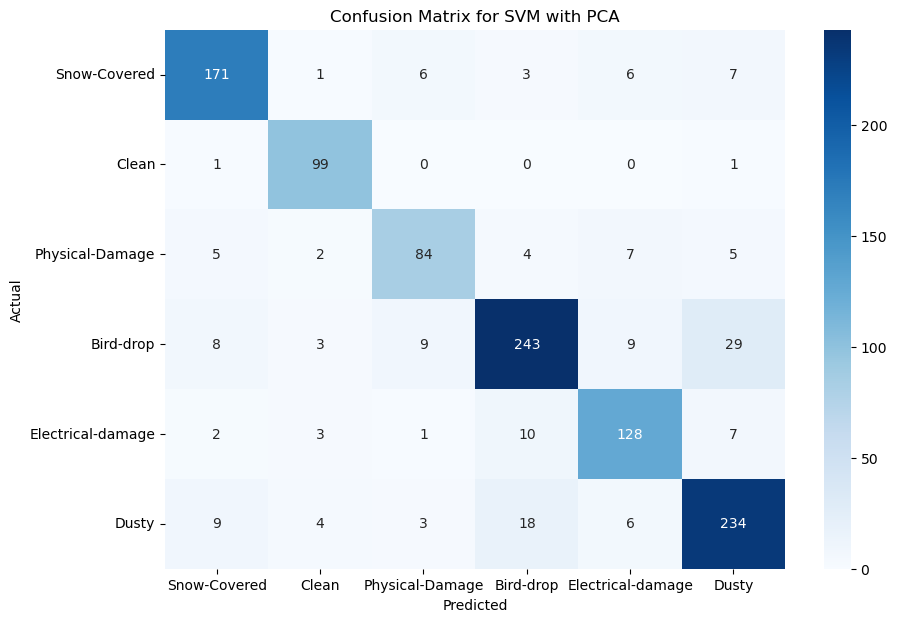

                   precision    recall  f1-score   support

     Snow-Covered       0.87      0.88      0.88       194
            Clean       0.88      0.98      0.93       101
  Physical-Damage       0.82      0.79      0.80       107
        Bird-drop       0.87      0.81      0.84       301
Electrical-damage       0.82      0.85      0.83       151
            Dusty       0.83      0.85      0.84       274

         accuracy                           0.85      1128
        macro avg       0.85      0.86      0.85      1128
     weighted avg       0.85      0.85      0.85      1128



In [8]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred_pca)

# Plot confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for SVM with PCA')
plt.show()

# Print classification report for additional metrics
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_pca, target_names=classes))